<a href="https://colab.research.google.com/github/SharanyaReddy27/BlogApp/blob/master/week12MDS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
# 1. Import libraries and load dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Load dataset
df = pd.read_csv("/house_price_regression_dataset.csv")

print("First 5 records:")
print(df.head())

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns)


First 5 records:
   Square_Footage  Num_Bedrooms  Num_Bathrooms  Year_Built  Lot_Size  \
0            1360             2              1        1981  0.599637   
1            4272             3              3        2016  4.753014   
2            3592             1              2        2016  3.634823   
3             966             1              2        1977  2.730667   
4            4926             2              1        1993  4.699073   

   Garage_Size  Neighborhood_Quality   House_Price  
0            0                     5  2.623829e+05  
1            1                     6  9.852609e+05  
2            0                     9  7.779774e+05  
3            1                     8  2.296989e+05  
4            0                     8  1.041741e+06  

Shape:
(1000, 8)

Columns:
Index(['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price'],
      dtype='object')


In [21]:
# 2. Check missing values

print("\nMissing values:")
print(df.isnull().sum())

df = df.dropna()

print("\nShape after removing missing values:")
print(df.shape)


Missing values:
Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64

Shape after removing missing values:
(1000, 8)


In [22]:
# 3. Select independent variables

X = df[
    [
        "Square_Footage",
        "Num_Bedrooms",
        "Num_Bathrooms",
        "Year_Built",
        "Lot_Size",
        "Garage_Size",
        "Neighborhood_Quality"
    ]
]

print("\nIndependent variables:")
print(X.head())


Independent variables:
   Square_Footage  Num_Bedrooms  Num_Bathrooms  Year_Built  Lot_Size  \
0            1360             2              1        1981  0.599637   
1            4272             3              3        2016  4.753014   
2            3592             1              2        2016  3.634823   
3             966             1              2        1977  2.730667   
4            4926             2              1        1993  4.699073   

   Garage_Size  Neighborhood_Quality  
0            0                     5  
1            1                     6  
2            0                     9  
3            1                     8  
4            0                     8  


In [23]:
# 4. Select dependent variable

Y = df["House_Price"]

print("\nDependent variable:")
print(Y.head())


Dependent variable:
0    2.623829e+05
1    9.852609e+05
2    7.779774e+05
3    2.296989e+05
4    1.041741e+06
Name: House_Price, dtype: float64


In [24]:
# 5. Create Linear Regression model

model = LinearRegression()

model.fit(X, Y)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [25]:
# 6. Predict house prices

Y_pred = model.predict(X)

print("\nActual House Prices:")
print(Y.head())

print("\nPredicted House Prices:")
print(Y_pred[:5])


Actual House Prices:
0    2.623829e+05
1    9.852609e+05
2    7.779774e+05
3    2.296989e+05
4    1.041741e+06
Name: House_Price, dtype: float64

Predicted House Prices:
[ 266715.18488881  976971.52275521  790951.85250057  219312.31145994
 1052346.82702956]


In [26]:
# 7. Calculate R²

r2 = r2_score(Y, Y_pred)

print("\nR² =", r2)


R² = 0.9985171191457451


In [27]:
# 8. Display coefficients

print("\nIntercept:")
print(model.intercept_)

print("\nCoefficients:")

for column, coefficient in zip(X.columns, model.coef_):
    print(column, ":", coefficient)


Intercept:
-2006987.6502154751

Coefficients:
Square_Footage : 199.7564113379702
Num_Bedrooms : 10170.954554850374
Num_Bathrooms : 8244.53504682125
Year_Built : 991.4681533129806
Lot_Size : 14919.323179010331
Garage_Size : 5158.063759106435
Neighborhood_Quality : 80.61739970822327


In [28]:
# 9. Calculate residuals

residuals = Y - Y_pred

print("\nResiduals:")
print(residuals.head())


Residuals:
0    -4332.332615
1     8289.331735
2   -12974.462382
3    10386.607204
4   -10605.968105
Name: House_Price, dtype: float64


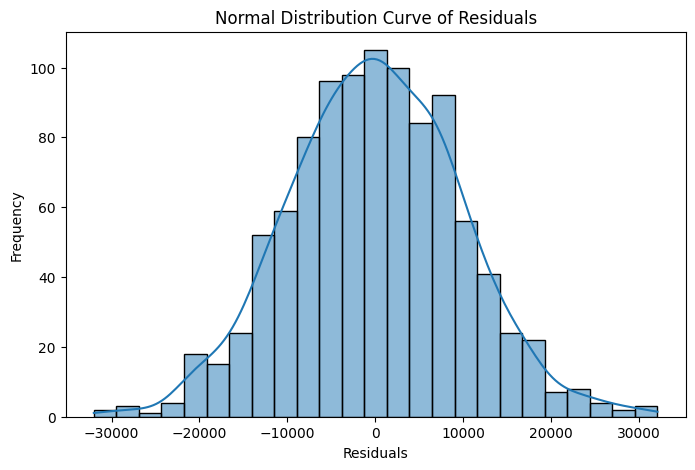

In [29]:
# 10. Normal Distribution Curve

plt.figure(figsize=(8, 5))

sns.histplot(residuals, kde=True)

plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Normal Distribution Curve of Residuals")

plt.show()

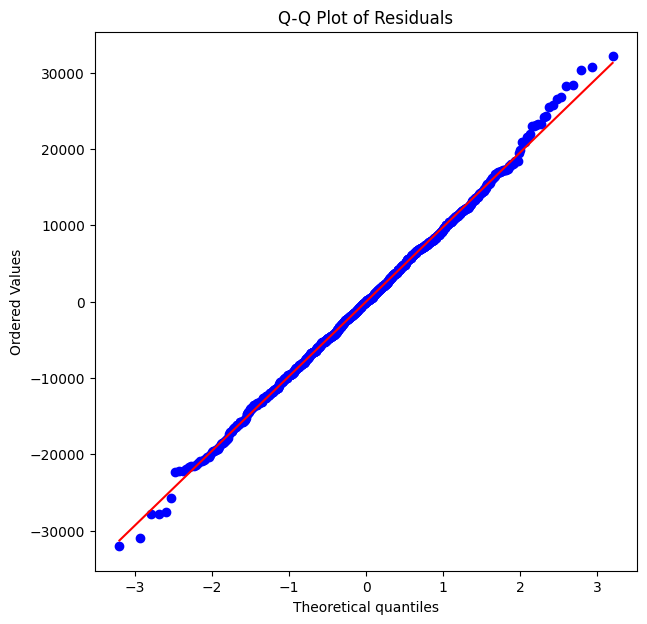

In [30]:
# 11. Q-Q Plot

plt.figure(figsize=(7, 7))

stats.probplot(residuals, dist="norm", plot=plt)

plt.title("Q-Q Plot of Residuals")

plt.show()

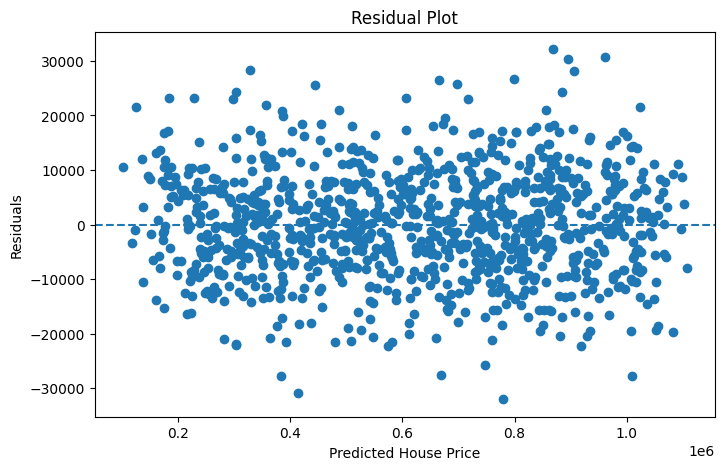

In [31]:
# 12. Residual Plot

plt.figure(figsize=(8, 5))

plt.scatter(Y_pred, residuals)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted House Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()